# Assignment 3: *Synapses*

In this assignment, you will implement models of synaptic transmission from the lecture. You will also compare different synapse models to experimental data. The final exercise will be on synaptic learning according to the BCM rule. 

## Installing Julia

The assignment will be done in the Julia programming language which we will also use in the following two assignments. Julia works best with VSCode. What you need to do is the following three things:
1. Install Julia from https://julialang.org/downloads/
2. Add the IJulia package to run notebooks: in the Julia REPL, type ```using Pkg```, then ```Pkg.add("IJulia")```
3. Launch a Jupyter session and select the Julia kernel 

Some packages that we will need are part of the basic Julia distribution and can be loaded via ```using PackageName```. To add other packages from within a notebook, use ```import Pkg; Pkg.add("PackageName")```. Once the package is compiled, remove this line from the code cell again. If you are used to Python (i.e., the Past) and have trouble with Julia (i.e., the Future), you can use a code converter such as [this one](https://www.codeconvert.ai/python-to-julia-converter) for help.


### Exercise 1

**Implement a single-exponential synapse.** In the first exercise, we want to model a synapse that responds to an input spike with an instantaneous rise in conductance,u followed by an exponential decay:

$$g(t) = \hat{g}_{syn}\cdot e^{-(t-t_0)/\tau}$$

1. Simulate the synaptic conductance $g$ for a duration of 50ms, at a temporal resolution of 0.01ms, in response to a single pre-synaptic spike occurring at 20ms. For the synaptic parameters, use a decay time constant of 1.7ms and a peak conductance of 2.5.

3. To do this, write a function that takes as arguments a point in time $t$ and a spike time $t_0$, and returns the value of the synaptic conductance $g$ at this time. Then *broadcast* this function over the vector of simulation time steps (Note: this is just a suggestion, you can do this whichever way you find most intuitive).

4. Plot the input spike train and the conductance over time as two subplots, stacked on top of one another. Put appropriate labels on the axes. Make sure to convert the simulation time steps (tick marks on the x-axis) to real time, measured in milliseconds. <div style="text-align: right"> **3 points** </div>

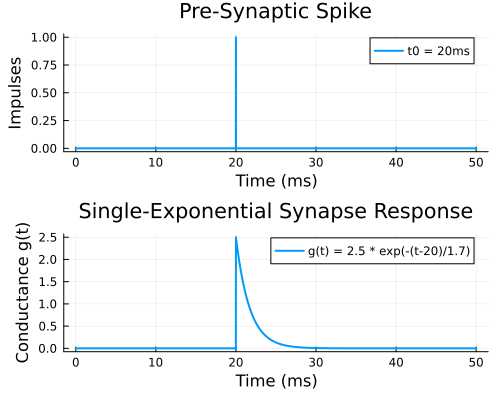

In [1]:
using Plots

# simulation parameters
# your code here
obs_time = 50
step_size = 0.01
t0 = 20
decay_constant = 1.7
peak = 2.5
t =  0:step_size:obs_time
n_steps = length(t)

#we want to initialize an array
g = zeros(n_steps)


# plot pre-synaptic spike
pre_synaptic_spike = [time == t0 ? 1.0 : 0.0 for time in t] 
p1 = plot(t, pre_synaptic_spike, 
     xlabel="Time (ms)", 
     ylabel="Impulses", 
     title="Pre-Synaptic Spike",
     label="t0 = 20ms",
     linewidth=2,
     legend=:topright)


# function to calculate the synaptic conductance over time
for i in 1:n_steps
    time = t[i]
    if time >= t0
        g[i] = peak * exp(-(time-t0)/decay_constant) 
    else
        g[i]= 0.0
    end
end




# put conductance into another plot
p2 = plot(t, g, 
     xlabel="Time (ms)", 
     ylabel="Conductance g(t)", 
     title="Single-Exponential Synapse Response",
     label="g(t) = 2.5 * exp(-(t-20)/1.7)",
     linewidth=2,
     legend=:topright)

# plot both spike input and synaptic conductance together
plot(p1, p2, layout=(2,1), size=(500, 400))

### Exercise 2

**Multiple input spikes and convolution.** Mathematically, the conductance response can also be understood in terms of the convolution of a synaptic kernel with an input spike train. Suppose in the image below (left), $f$ is a spike and $g$ is the synaptic kernel. To convolve $f$ with $g$, one would flip $g$ horizontally and slide it continuously over $f$ (see illustration on the right). The convolution $f\ast g$ at any point in time is the size of the area that is created by intersecting the two function graphs. Thus, convolution is an integral and $f\ast g = g\ast f$ (commutativity).

<a href="https://ibb.co/MDpqCntg"><img src="https://i.ibb.co/RpPLD2sg/Convolution.png" alt="Convolution" border="0" width=600/></a>


In this exercise you will use the convolution function ```conv``` from the Julia package ```DSP``` (Digital Signal Processing) in order to replicate the synaptic response from Exercise 1, but this time for multiple input spikes.

1. Use the same simulation parameters and synaptic parameters as above, and create input spikes at 5, 10, 12, 20, 40, and 41ms.
3. Define the synaptic kernel which is an exponential decay (from time 0) with the same shape as the synaptic conductance in the previous exercise.
4. Convolve the kernel with the input spike train using the ```conv``` function.
5. Plot the kernel and the synaptic response side-by-side, for the duration of the simulation. <div style="text-align: right"> **4 points** </div>

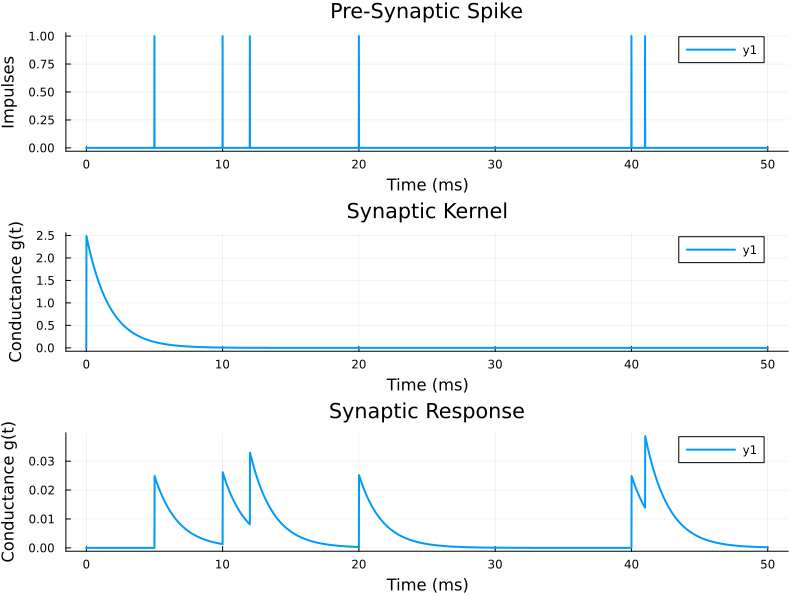

In [2]:
using DSP

# simulation parameters, from previous exercise
obs_time = 50
step_size = 0.01
t0 = 20
decay_constant = 1.7
peak = 2.5
t =  0:step_size:obs_time
n_steps = length(t)

#we want to initialize an array
g = zeros(n_steps)


# synaptic parameters, from previous exercise
# your code here

# create input
spike_times = [5.0,10.0,12.0,20.0,40.0, 41.0]
pre_synaptic_spike = [time in spike_times ? 1.0 : 0.0 for time in t] 
p1 = plot(
    t, pre_synaptic_spike,          # <-- first argument: x, second: y
    xlabel="Time (ms)", 
    ylabel="Impulses", 
    title="Pre-Synaptic Spike",
    linewidth=2,
    legend=:topright
)


# write kernel and plot
kernel = [time > 0 ? peak * exp(-time/decay_constant) : 0.0 for time in t]
p2 = plot(t, kernel, 
     xlabel="Time (ms)", 
     ylabel="Conductance g(t)", 
     title="Synaptic Kernel",
     linewidth=2,
     legend=:topright)


# convolve kernel with input
convoluted_output = conv(pre_synaptic_spike, kernel)[1:n_steps] * step_size

# plot synaptic conductance
p3 = plot(t, convoluted_output, 
     xlabel="Time (ms)", 
     ylabel="Conductance g(t)", 
     title="Synaptic Response",
     linewidth=2,
     legend=:topright)
# plot both graphs together
plot(p1, p2, p3, layout=(3,1), size=(800, 600))


### Exercise 3

**Synaptic currents and post-synaptic potentials.** Now use the convolutional approach from Exercise 2 to implement the alpha synapse model from the lecture. 

1. Write the kernel for the alpha synapse, with the same tim4. Similar to the lecture slide on *Multiple Input Spikes*, plot three stacked panels: the synaptic conductance on top (black), the PSC in the middle (blue) and the EPSP underneath (orange). <div style="text-align: right"> **4 points** </div>e constant as above, and compute the synaptic conductance using convolution for the same spike input as above.
2. Calculate the post-synaptic current (PSC) for an excitatory, *current-based* synapse. Use a constant membrane potential of -70mV and a scaling factor $\hat{g}_{syn} = 0.1$. Keep in mind that, by convention, the PSC is negative.
3. Then, calculate the post-synaptic potential (EPSP) by filtering the excitatory current through a neuron model with a membrane time constant of 20ms and a capacitance of 300pF. 


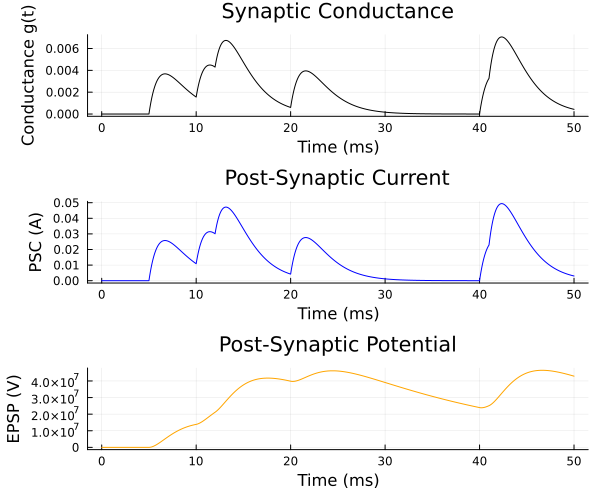

In [3]:
# synaptic parameters, from previous exercise
# your code here
obs_time = 50
step_size = 0.01
t0 = 20
decay_constant = 1.7
peak = 2.5
t =  0:step_size:obs_time
n_steps = length(t)

#we want to initialize an array
g = zeros(n_steps)




# create input, from prev
spike_times = [5.0,10.0,12.0,20.0,40.0, 41.0]
pre_synaptic_spike = [time in spike_times ? 1.0 : 0.0 for time in t] 


# write kernel and plot
kernel = [time >= 0 ? time/decay_constant * exp(-time/decay_constant) : 0.0 for time in t]

 plot(t, kernel, 
     xlabel="Time (ms)", 
     ylabel="Conductance g(t)", 
     title="Synaptic Kernel",
     linewidth=2,
     legend=:topright)


# write conductance and convolve
g_t = conv(pre_synaptic_spike, kernel)[1:n_steps] * step_size
p1 = plot(t, g_t, 
     xlabel="Time (ms)", 
     ylabel="Conductance g(t)", 
     title="Synaptic Conductance",
     linewidth=2,
     legend=:topright)


# post-synaptic current, current-based synapse (membrane voltage fixed at E_L)
g_syn = 0.1
V_m = -70.0
E_rev = 0.0

I_PSC = -g_syn * g_t * (V_m - E_rev)

#for the post-synaptic potential:
t_m = 20.0
C_m = 0.3e-9 
V = [0.0 for time in t]
for i in 2:length(V)
    V[i] = V[i-1] + step_size/t_m * (-V[i-1] + I_PSC[i]/C_m)
end

# filter current through model of membrane dynamics (without spike threshold)
# your code here

# plot everything on top of each other
p1 = plot(t, g_t, color=:black, xlabel="Time (ms)", ylabel="Conductance g(t)", title="Synaptic Conductance", legend=false)
p2 = plot(t, I_PSC, color=:blue, xlabel="Time (ms)", ylabel="PSC (A)", title="Post-Synaptic Current", legend=false)
p3 = plot(t, V, color=:orange, xlabel="Time (ms)", ylabel="EPSP (V)", title="Post-Synaptic Potential", legend=false)

plot(p1, p2, p3, layout=(3,1), size=(600,500))

### Exercise 4

**Double exponential synapse, conductance-based.** The convolution approach is convenient, but it requires that we know the entire synaptic input spike train in advance. When simulating spiking networks this is usually not the case. Rather, we compute the state of the network (including spikes and synaptic responses) one timestep $dt$ at a time. So, we return to incremental modeling of synaptic conductances using the approach of Exercise 1 (i.e., without convolution). This time we want to model a double exponential synapse, and post-synaptic currents that are *conductance-based*. The "recipe" for this can be found on the lecture slide called *Simulating A Double-Exponential Synapse*.

1. Use a synaptic rise time constant of 1.7ms and a decay time constant of 15ms. Again, we use the same spike input as above.
2. Iteratively calculate the synaptic conductance $g$, the conductance-based post-synaptic current, and the *inhibitory* post-synaptic potential, using the same neuronal filter as before.
3. As in the previous exercise, plot the three dynamic variables with appropriate colors and axis labels. <div style="text-align: right"> **4 points** </div>

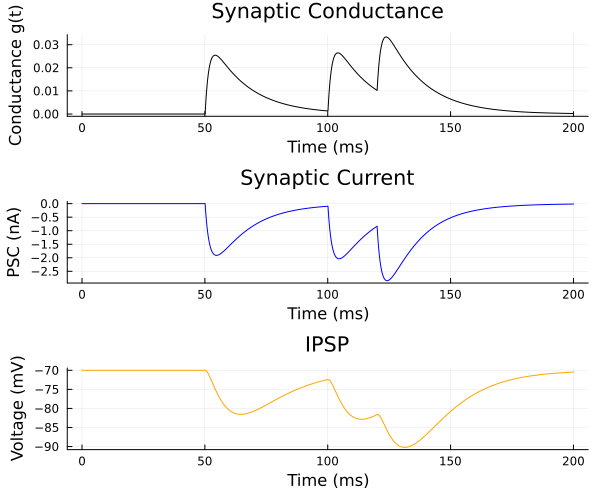

In [4]:
# double exponential synapse parameters
t_rise = 1.7
t_decay = 15.0
E_rev = 0.0       
E_l = -70.0        
g_l = 0.1
C_m = 1.0
step_size = 0.1
t = 0:step_size:200


# initialize stuff
V = fill(E_l, length(t))
rise = zeros(length(t))
decay = zeros(length(t))
g_t = zeros(length(t))
I_syn = zeros(length(t))
w = 0.5


for i in 2:length(t)
    # updates
    rise[i] = rise[i-1] - step_size/t_rise * rise[i-1] + w*pre_synaptic_spike[i-1]
    decay[i] = decay[i-1] - step_size/t_decay * decay[i-1] + w*pre_synaptic_spike[i-1]

    # compute conductance
    g_t[i] = (decay[i] - rise[i]) / (t_decay - t_rise)

    # PSC
    I_syn[i] = g_t[i] * (V[i-1] - E_rev)
    
    # IPSP
    V[i] = V[i-1] + step_size / C_m * (-g_l * (V[i-1] - E_l) + I_syn[i])
end

# plot conductance, PSC and IPSP together
p1 = plot(t, g_t, color=:black, xlabel="Time (ms)", ylabel="Conductance g(t)", title="Synaptic Conductance", legend=false)
p2 = plot(t, I_syn, color=:blue, xlabel="Time (ms)", ylabel="PSC (nA)", title="Synaptic Current", legend=false)
p3 = plot(t, V, color=:orange, xlabel="Time (ms)", ylabel="Voltage (mV)", title="IPSP", legend=false)

plot(p1, p2, p3, layout=(3,1), size=(600,500))

### Exercise 5

**Fitting synapse models to experimental data.** The file ```test_trace.csv``` that comes with this exercise contains empirical data from *in vivo* voltage clamp recordings of cortical pyramidal neurons. It is basically one long timeseries of excitatory post-synaptic currents (EPSCs). In this exercise, you'll first prepare this data for analysis, and then fit different synapse models to the scaled average EPSC, determine the parameters of the best fit, and measure the explained variance of these synapse models.

The cell below shows the Julia packages that are needed and slurps the ```.csv``` file into a variable called ```data```. Inspect the data. Use the package ```Peaks``` to find the local minima of the EPSC that have a value of 200, or less. Plot the first 1000 data points and mark the minima with a special plotting symbol (e.g., a circle or cross). <div style="text-align: right"> **2 points** </div>

In [5]:
using CSV, DataFrames, Peaks

# load data from file
data = CSV.File("./test_trace.csv", header=false) |> DataFrame
y = data[:, 1]  
#converting it into a vector
y = collect(y)

# get the peaks (time points of the minima), and their values
min_indices = argminima(y)


# retain only the peaks that are lower than 200
min_indices = filter(i -> y[i] ≤ -200, min_indices)


# plot timeseries for 1000 steps and add label to peaks
N = 1000
plot(1:N, y[1:N], label="EPSC")
ixs = filter(i -> i ≤ N, min_indices_filt)
scatter!(ixs, y[ixs], marker=:circle, c=:red, label="minima ≤ -200")

UndefVarError: UndefVarError: `min_indices_filt` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Now extract all EPSC traces around these minima x in the interval ```x-3``` to ```x+13``` time steps (for the entire data set), plot all these traces (use an alpha level of 0.03 for each line), and also add the mean over these traces. In a second plot, plot this mean, together with a ribbon/confidence interval around the mean that shows +- the standard deviation at each time point. In a third plot, plot the mean that is scaled down by subtracting the overall minimum EPSC. Label all plots appropriately with axes labels and plot titles.<div style="text-align: right"> **3 points** </div>

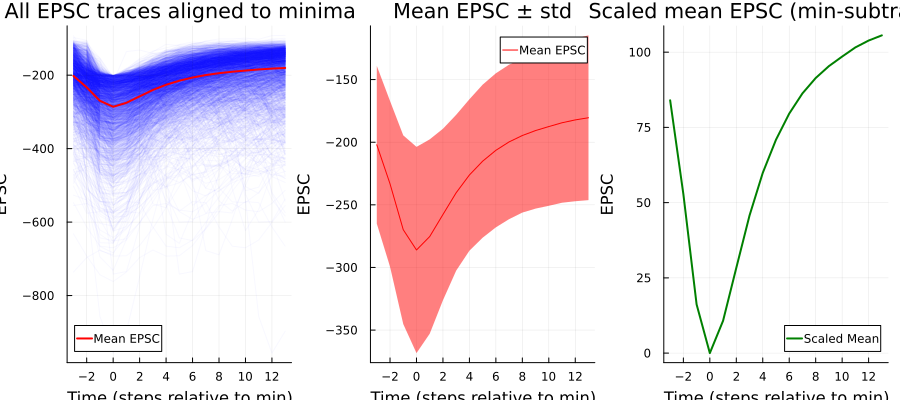

In [6]:
using StatsBase # provides functions like "mean"

# align EPSCs around peaks and plot
offsets = -3:13
window_len = length(offsets)

#avoinding stuff too close to edges
valid_mins = filter(x -> x-3 ≥ 1 && x+13 ≤ length(y), min_indices)

#im doing a matrix with the intervals we're considering 
traces = [y[x .+ offsets] for x in valid_mins] #this should end up being a list of small vectors of length 17
traces_mat = reduce(vcat, [t' for t in traces]) #vertically, i get a matrix with shape [num of min, 17]


# plot mean with standard deviation as a ribbon
mean_trace = mean(traces_mat, dims=1)[:]
std_trace  = std(traces_mat, dims=1)[:]

#plotting
p11 = plot(title="All EPSC traces aligned to minima",
     xlabel="Time (steps relative to min)", ylabel="EPSC")
for t in eachrow(traces_mat)
    plot!(offsets, t, alpha=0.03, color=:blue, label="")
end
plot!(offsets, mean_trace, color=:red, lw=2, label="Mean EPSC")

p12 = plot(offsets, mean_trace, ribbon=std_trace, color=:red,
     title="Mean EPSC ± std", xlabel="Time (steps relative to min)",
     ylabel="EPSC", label="Mean EPSC")

# scale mean PSC by subtracting minimum
scaled_mean = mean_trace .- minimum(mean_trace)
p13 = plot(offsets, scaled_mean, color=:green, lw=2,
     title="Scaled mean EPSC (min-subtracted)",
     xlabel="Time (steps relative to min)", ylabel="EPSC",
     label="Scaled Mean")


# plot three panels (here called p11, p12, p13) next to each other
plot(p11,p12,p13, layout = grid(1, 3), size=(900,400))

The scaled grand mean obtained above will now be used to fit two parameterized synapse models. To do this curve fitting, use the function ```curve_fit``` from the package ```LsqFit```. Here is what needs to be done:

1. Create an input spike train that has one spike at time point 2 and zeros everywhere else.
2. Now use an alpha synapse model, and a double exponential synapse model, and write functions that return the corresponding EPSC. You can use convolution and current-based synapses here.
3. Feed these functions and the experimental trace (scaled mean) into ```curve_fit```, together with the synaptic parameters you want to optimize. Consult the documentation of ```curve_fit``` from ```LsqFit``` for an example. The parameters that can, or should be, optimized include synaptic time constants, peak conductance and also an initial current value before the input spike. All other parameters should be considered fixed in synaptic physiology (e.g., the synaptic reversal potential). 
4. The fitted model parameters can then be used to create a prediction from the two synapse models. For both synapse models, plot the empirical EPSC together with the model predictions. The fit for both models should be pretty good, based on eyeballing alone.
5. Create a function to calculate the R-squared ($R^2$) between the empirical EPSC and model predictions. To do this, consult the [wiki](https://en.wikipedia.org/wiki/Coefficient_of_determination) on how the $R^2$ is computed. Quantify the explained variance for the fitted alpha synapse and double exponential synapse. Which of the two synapse models fits better? Which of the two synapse models should be used? Note: it should be possible to obtain a fit of at least $R^2 > 95\%$. <div style="text-align: right"> **5 points** </div>

Explained variance for alpha synapse is 75.217%.
Explained variance for double exponential synapse is 75.224%.

Fitted parameters for alpha synapse:
  tau = 12.223
  g_max = 1.044
  I0 = 31.972

Fitted parameters for double exponential synapse:
  tau_rise = 5.792
  tau_decay = 53.8
  g_max = 1.575
  I0 = 31.867


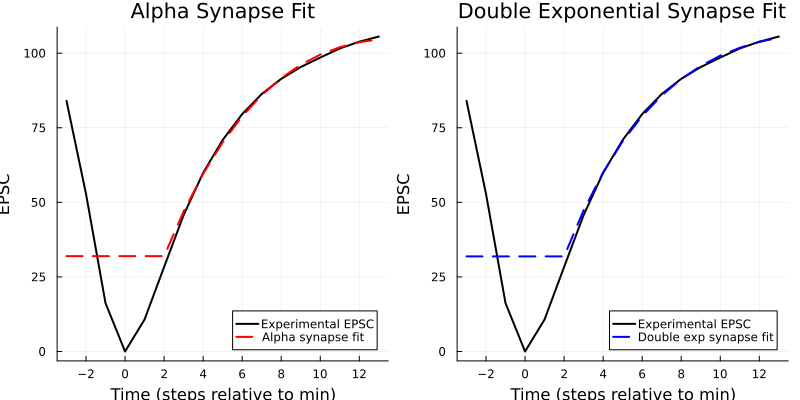

In [44]:
using LsqFit, Printf

# Create function to compute R²
function Rsquared(observed, predicted)
    ss_res = sum((observed .- predicted).^2)
    ss_tot = sum((observed .- mean(observed)).^2)
    return 1 - (ss_res / ss_tot)
end

# Create spike input (one spike at time point 2)
spike_train = zeros(length(offsets))
spike_train[5] = 1.0  # time point 2 in our offset iis equal to 5 since offset -3:13, so index 5 = time 2

# starting point for parameeters
E_rev = 0.0    
E_leak = -70.0 
# Initializing parameter guesses
p0_alpha = [5.0, 100.0, -50.0]  
p0_double = [1.0, 5.0, 100.0, -50.0]  

# Synapse model functions:
#alpha function
function alpha_synapse(tau, g_max, I0, t, spike)
    kernel = zeros(length(t))
    for (i, time) in enumerate(t)
        if time >= 2  # since we established spike happens at time 2
            kernel[i] = g_max * (time - 2)/tau * exp(1 - (time - 2)/tau)
        end
    end
    return I0 .+ kernel .* (E_rev - E_leak)
end

# Double exponential 
function double_exp_synapse(tau_rise, tau_decay, g_max, I0, t, spike)
    kernel = zeros(length(t))
    for (i, time) in enumerate(t)
        if time >= 2  # spike happens at time 2
            normalized_time = time - 2
            kernel[i] = g_max * (exp(-normalized_time/tau_decay) - exp(-normalized_time/tau_rise))
        end
    end
    return I0 .+ kernel .* (E_rev - E_leak)
end



# Wrapper functions for curve_fit
alpha_model(t, p) = alpha_synapse(p[1], p[2], p[3], t, spike_train)
double_exp_model(t, p) = double_exp_synapse(p[1], p[2], p[3], p[4], t, spike_train)

# Prepare data for fitting
t = collect(offsets)
y_data = scaled_mean



# Perform curve fitting
fit_alpha = curve_fit(alpha_model, t, y_data, p0_alpha)
fit_double = curve_fit(double_exp_model, t, y_data, p0_double)

# Get fitted parameters and predictions
params_alpha = fit_alpha.param
params_double = fit_double.param

pred_alpha = alpha_model(t, params_alpha)
pred_double = double_exp_model(t, params_double)

# Calculate R² values with function from above
r2_alpha = Rsquared(y_data, pred_alpha)
r2_double = Rsquared(y_data, pred_double)

# Print results from instruction
@printf "Explained variance for alpha synapse is %.3f%%.\n" 100*r2_alpha
@printf "Explained variance for double exponential synapse is %.3f%%.\n" 100*r2_double

# Plot results
p1 = plot(t, y_data, label="Experimental EPSC", linewidth=2, color=:black)
plot!(t, pred_alpha, label="Alpha synapse fit", linewidth=2, color=:red, linestyle=:dash)
title!("Alpha Synapse Fit")
xlabel!("Time (steps relative to min)")
ylabel!("EPSC")

p2 = plot(t, y_data, label="Experimental EPSC", linewidth=2, color=:black)
plot!(t, pred_double, label="Double exp synapse fit", linewidth=2, color=:blue, linestyle=:dash)
title!("Double Exponential Synapse Fit")
xlabel!("Time (steps relative to min)")
ylabel!("EPSC")


# Print fitted parameters
println("\nFitted parameters for alpha synapse:")
println("  tau = ", round(params_alpha[1], digits=3))
println("  g_max = ", round(params_alpha[2], digits=3))
println("  I0 = ", round(params_alpha[3], digits=3))

println("\nFitted parameters for double exponential synapse:")
println("  tau_rise = ", round(params_double[1], digits=3))
println("  tau_decay = ", round(params_double[2], digits=3))
println("  g_max = ", round(params_double[3], digits=3))
println("  I0 = ", round(params_double[4], digits=3))


plot(p1, p2, layout=(1,2), size=(800,400))


In [8]:
# now do exactly the same as above, but for a double exponential synapse
# your code here

@printf "Explained variance for double-exponential synapse is %.3f%%." 100*Rsquared(y, pred)

# plot 
# your code here

UndefVarError: UndefVarError: `Rsquared` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Exercise 6

**Bienenstock-Cooper-Munro learning rule.** In this exercise, you will implement the Bienenstock-Cooper-Munro (BCM) learning rule from the lecture and explore some of its properties.

1. Implement the basic BCM rule (with fixed threshold) from the lecture and recreate the plot that shows the regions of LTP/LTD relative to a fixed threshold. Label and annotate the plot appropriately.
2. Now simulate an adaptive threshold for this learning rule. Create a u-shaped timeseries of post-synaptic firing rates between 0 and 10Hz (with white noise added). Calculate the adaptive threshold value over time and plot it side-by-side with the post-synaptic rate. Is the outcome what you expected?
3. In the lecture it was argued that BCM with an adaptive threshold would lead to synaptic competition and the development of receptive fields. In this part of the exercise, we want to "verify" this story by means of a simulation. Create a small network, as shown on the slide on BCM, with four input neurons and one post-synaptic neuron. As synapses use real numbers $ w_{ij}$ and dot products to compute inputs to the post-synaptic neuron. Put low, random input rates on the pre-synaptic neurons and initialize all weights to a common value. Simulate the network for 100 time steps. After 30 time steps, crank up the input rate on one of the neurons, and switch back to the initial rate after 70 time steps. Update the weights according to BCM with adaptive threshold. Keep track of weights, post-synaptic rates and thresholds and plot the three variables three side-by-side. Find parameters such that all weights get depressed initially, followed by a period of potentiation, and another period of depression. Ideally, the outcome should be that one of the weights gets potentiated more strongly than the other three weights. <div style="text-align: right"> **8 points** </div>

In [9]:
# sub-exercise 1
using LaTeXStrings # this can be used to include latex code in plots/annotations

# BCM with fixed threshold
# your code here

# recreate plot
# your code here

ArgumentError: ArgumentError: Package LaTeXStrings not found in current path.
- Run `import Pkg; Pkg.add("LaTeXStrings")` to install the LaTeXStrings package.

In [10]:
# sub-exercise 2

# calculate average of squared post-synaptic firing rate
# your code here

# create input and plot
# your code here

# initialize stuff to record theta
# your code here

# simulate adaptive theta and plot
# your code here

# plot input and theta side-by-side
# your code here

In [11]:
# sub-exercise 3

# write function to update weights
# your code here

# write function to simulate weight update under adaptive BCM
# your code here

# run adaptive BCM and record weights, theta, and post-synaptic rate, plot everything side-by-side
# your code here